# LAPORAN TUGAS PROYEK PENGENALAN POLA

**JUDUL PROYEK :** Klasifikasi Nominal Uang Kertas Rupiah Berbasis Citra Digital Menggunakan Ekstraksi Fitur Warna dan Tekstur  
**MATA KULIAH :** Pengenalan Pola  
**DOSEN PENGAMPU:** Prof. I Gede Pasek Suta Wijaya  

**Disusun Oleh (Kelompok):**
1. Fadlullah Hasan - F1D02310008
2. Muhammad Ihdal Fahroni - F1D02310017
3. Ida Bagus Amanta Pradipa Krishna - F1D02310059

**PROGRAM STUDI :** Teknik Informatika FT-UNRAM  
**TAHUN         :** 2026 

---
## Summary
Proyek ini bertujuan mengembangkan model yang mampu mengenali dan membedakan nominal uang kertas rupiah (2k, 5k, 10k, 20k, 50k, 100k) berdasarkan citra digital secara otomatis. Masalah utama dalam klasifikasi uang kertas di dunia nyata adalah variasi intensitas cahaya dan kekusutan kertas. Dari tinjauan *State of The Art* (SOTA), klasifikasi dengan warna RGB terbukti rentan terhadap perubahan cahaya. Oleh karena itu, proyek ini membandingkan 4 skenario ekstraksi fitur: RGB murni, HSV murni, RGB + GLCM (tekstur), dan HSV + GLCM. Klasifikasi dilakukan menggunakan algoritma *K-Nearest Neighbors* (KNN) dan *Random Forest*. Hasil akhir menunjukkan bahwa model *Random Forest* dengan fitur HSV + GLCM memberikan performa tertinggi dengan akurasi pengujian (test) dan validasi silang (CV) yang stabil (di atas 90%), melampaui performa fitur warna RGB konvensional.

**Kata Kunci:** Uang Kertas Rupiah, Ekstraksi Fitur, HSV, GLCM, Random Forest, K-Nearest Neighbors.

---
## 1. PENDAHULUAN
### 1.1 Latar Belakang
Pengenalan nominal mata uang secara otomatis sangat krusial untuk teknologi transaksi modern (seperti *vending machine* atau ATM) serta sebagai alat bantu (*assistive technology*) bagi penyandang tunanetra. Berdasarkan kajian literatur terdahulu, penelitian oleh Andhika Ryan Pratama dkk. (2020) telah melakukan klasifikasi uang kertas (Rp2.000 & Rp5.000) menggunakan ruang warna RGB dan KNN dengan hasil yang cukup baik pada dataset kecil. 

Namun, penggunaan ruang warna RGB memiliki kelemahan mendasar karena ia mengikat informasi warna dengan intensitas cahaya, sehingga performanya menurun drastis pada foto yang gelap atau terlalu terang. Oleh karena itu, proyek ini diangkat untuk menyempurnakan pendekatan tersebut dengan membandingkan fitur RGB dengan HSV (yang memisahkan kromatisitas dari cahaya), serta menambahkan ekstraksi tekstur menggunakan *Gray Level Co-occurrence Matrix* (GLCM) untuk melihat seberapa jauh fitur tekstur membantu mesin membedakan corak nominal uang.

### 1.2 Rumusan Masalah
1. Bagaimana cara mengekstrak fitur/karakteristik warna dan tekstur yang tepat dari dataset citra uang kertas yang rentan terhadap variasi pencahayaan?
2. Bagaimana performa model algoritma KNN dan Random Forest dalam mengenali pola nominal uang rupiah berdasarkan kombinasi fitur yang diberikan?

### 1.3 Tujuan Proyek
1. Menerapkan metode pra-pemrosesan dan ekstraksi fitur gabungan (HSV, RGB, GLCM) untuk mengenali dan mengklasifikasikan pola uang kertas rupiah.
2. Menganalisis tingkat akurasi dan performa model berdasarkan parameter dan skenario fitur yang dievaluasi menggunakan *Classification Report* dan *Confusion Matrix*.

---
## 2. DATASET DAN PRA-PROSES DATA (PREPROCESSING)
### 2.1 Deskripsi Dataset
* **Sumber Data:** Pengambilan Data Primer (Foto uang kertas lokal)
* **Jumlah Data:** Terdiri dari ratusan sampel citra, yang nantinya akan dibagi menggunakan rasio 80% data latih (train) dan 20% data uji (test).
* **Fitur/Atribut:** Citra diekstrak menjadi data tabular. Fitur terdiri dari nilai Histogram Warna (1D) dan parameter Tekstur GLCM (Contrast, Homogeneity, Energy, Correlation) dari gambar beresolusi 256x256 piksel.
* **Target/Kelas (Label):** `2k`, `5k`, `10k`, `20k`, `50k`, `100k`.

In [1]:
# Import Library & Load Dataset info
import os
import random
from pathlib import Path
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm
import warnings

from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# Konfigurasi Parameter
DATASET_DIR = Path("Dataset")
RANDOM_SEED = 42
TARGET_WIDTH, TARGET_HEIGHT = 256, 256

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
print(f"Dataset Target/Kelas (Label): {CLASS_NAMES}")

# Pembuatan Direktori Penyimpanan
os.makedirs("features", exist_ok=True)
os.makedirs("models/knn", exist_ok=True)
os.makedirs("models/rf", exist_ok=True)

Dataset Target/Kelas (Label): ['100k', '10k', '1k', '20k', '2k', '50k', '5k']


### 2.2 Pra-proses Data (Data Preprocessing)
Langkah-langkah yang dilakukan untuk menyiapkan data sebelum masuk ke model ekstraksi:
* **HSV Masking & Otsu Thresholding:** Mengisolasi dan menyeleksi objek uang kertas dari latar belakang gambar.
* **Cropping:** Memotong batas gambar sesuai dengan *bounding box* objek uang kertas yang terdeteksi.
* **Resize:** Mengubah resolusi gambar objek yang telah dipotong menjadi ukuran seragam 256x256 piksel dengan teknik *padding*.

In [2]:
def mask_hsv(image_bgr, gray_threshold=25, min_area_ratio=0.01, kernel_size=7):
    work_img = image_bgr.copy()
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, gray_threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    h, w = mask.shape
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    mask = mask | cv2.bitwise_not(flood)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)
    if num_labels > 1:
        largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        if stats[largest_idx, cv2.CC_STAT_AREA] >= (min_area_ratio * h * w):
            refined[labels == largest_idx] = 255
        else: refined = mask.copy()
    else: refined = mask.copy()
    return work_img, refined, cv2.bitwise_and(work_img, work_img, mask=refined)

def crop_to_mask(image_bgr, mask, pad_ratio=0.05):
    coords = cv2.findNonZero(mask)
    if coords is None: return image_bgr
    x, y, w, h = cv2.boundingRect(coords)
    pad = int(max(w, h) * pad_ratio)
    h_img, w_img = image_bgr.shape[:2]
    return image_bgr[max(y-pad, 0):min(y+h+pad, h_img), max(x-pad, 0):min(x+w+pad, w_img)]

def resize(image_bgr, target_width, target_height, fill_value=0):
    h, w = image_bgr.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    output = np.full((target_height, target_width, 3), fill_value, dtype=np.uint8)
    y_off, x_off = (target_height - new_h) // 2, (target_width - new_w) // 2
    output[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return output

def preprocess_for_features(image_bgr):
    _, mask, segmented = mask_hsv(image_bgr)
    return resize(crop_to_mask(segmented, mask), TARGET_WIDTH, TARGET_HEIGHT)

---
## 3. METODOLOGI DAN ARSITEKTUR MODEL
### 3.1 Ekstraksi Fitur (Feature Extraction)
Penelitian ini menggunakan metode konvensional berbasis statistik citra:
* **Warna (HSV dan RGB):** Diekstrak menggunakan fungsi *calcHist* dari OpenCV yang membagi gambar ke dalam grid (4 kuadran) untuk menangkap distribusi warna secara spasial.
* **Tekstur (GLCM):** Matriks *Gray Level Co-occurrence* digunakan untuk menghitung nilai korelasi spasial derajat keabuan (Contrast, Homogeneity, Energy, Correlation) pada berbagai sudut.
Seluruh fitur ini diekstrak dan disimpan dalam format Tabular (CSV).

In [3]:
def extract_hsv(image_bgr, grid_size=(2, 2), bins=8):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]
    gh, gw = grid_size
    features = []
    for i in range(gh):
        for j in range(gw):
            cell = hsv[int(i*h/gh):int((i+1)*h/gh), int(j*w/gw):int((j+1)*w/gw)]
            features.extend(cv2.normalize(cv2.calcHist([cell], [0], None, [bins], [0, 180]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [1], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [2], None, [bins], [0, 256]), None).flatten())
    return features

def extract_rgb(image_bgr, grid_size=(2, 2), bins=8):
    h, w = image_bgr.shape[:2]
    gh, gw = grid_size
    features = []
    for i in range(gh):
        for j in range(gw):
            cell = image_bgr[int(i*h/gh):int((i+1)*h/gh), int(j*w/gw):int((j+1)*w/gw)]
            features.extend(cv2.normalize(cv2.calcHist([cell], [0], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [1], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [2], None, [bins], [0, 256]), None).flatten())
    return features

def extract_glcm(image_bgr, levels=32):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray_q = np.clip(np.floor(gray.astype(np.float32) * levels / 256.0).astype(np.uint8), 0, levels - 1)
    glcm = graycomatrix(gray_q, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=levels, symmetric=True, normed=True)
    features = []
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        features.extend(graycoprops(glcm, prop).flatten())
    return features

# Looping Pembuatan Dataset
print("\n[INFO] Mengekstrak Fitur dari Seluruh Gambar...")
data_all = []

for class_name in CLASS_NAMES:
    class_dir = DATASET_DIR / class_name
    for img_file in tqdm(sorted(class_dir.glob("*.*")), desc=f"Kelas {class_name}"):
        if img_file.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]: continue
        img = cv2.imread(str(img_file))
        if img is None: continue
        
        processed = preprocess_for_features(img)
        row = {"filename": img_file.name, "label": class_name}
        
        feat_hsv = extract_hsv(processed)
        feat_rgb = extract_rgb(processed)
        feat_glcm = extract_glcm(processed)
        
        for i, val in enumerate(feat_hsv): row[f"HSV_{i}"] = val
        for i, val in enumerate(feat_rgb): row[f"RGB_{i}"] = val
        for i, val in enumerate(feat_glcm): row[f"GLCM_{i}"] = val
            
        data_all.append(row)

# Konversi dan Pisahkan ke 4 DataFrame Skenario
df_master = pd.DataFrame(data_all)
df_rgb = df_master[["filename", "label"] + [c for c in df_master.columns if "RGB_" in c]]
df_hsv = df_master[["filename", "label"] + [c for c in df_master.columns if "HSV_" in c]]
df_rgb_glcm = df_master[["filename", "label"] + [c for c in df_master.columns if "RGB_" in c or "GLCM_" in c]]
df_hsv_glcm = df_master[["filename", "label"] + [c for c in df_master.columns if "HSV_" in c or "GLCM_" in c]]

# Simpan CSV
df_rgb.to_csv("features/rgb.csv", index=False)
df_hsv.to_csv("features/hsv.csv", index=False)
df_rgb_glcm.to_csv("features/rgb_glcm.csv", index=False)
df_hsv_glcm.to_csv("features/hsv_glcm.csv", index=False)
print("[INFO] 4 Variasi Dataset (RGB, HSV, RGB+GLCM, HSV+GLCM) berhasil disimpan!")


[INFO] Mengekstrak Fitur dari Seluruh Gambar...


Kelas 5k: 100%|██████████| 50/50 [00:20<00:00,  2.42it/s]


[INFO] 4 Variasi Dataset (RGB, HSV, RGB+GLCM, HSV+GLCM) berhasil disimpan!


### 3.2 Arsitektur Model Pengenalan Pola
Proyek ini menggunakan dan membandingkan dua algoritma Machine Learning konvensional:
1. **K-Nearest Neighbors (KNN)**: Mengklasifikasikan kelas berdasarkan metrik jarak terdekat.
   * *Hyperparameter:* `n_neighbors`: 5
2. **Random Forest**: *Ensemble learning* yang membangun kumpulan pohon keputusan (Decision Trees) untuk klasifikasi yang tahan terhadap variansi tinggi.
   * *Hyperparameter:* `n_estimators`: 200, `random_state`: 42

---
## 4. IMPLEMENTASI DAN PENGUJIAN
### 4.1 Lingkungan Implementasi (Environment)
* **Bahasa Pemrograman:** Python
* **Library Utama:** Scikit-Learn (Pemodelan ML), OpenCV (Pemrosesan Citra), Pandas & NumPy (Manipulasi Array Tabular), Seaborn & Matplotlib (Visualisasi).
* **Perangkat Keras:** Spesifikasi Komputer Lokal / CPU standard.

### 4.2 Skenario Pengujian
* **Data Splitting:** Dataset dibagi secara statis menjadi data latih (80%) dan data uji (20%) menggunakan parameter *stratify* agar distribusi kelas merata.
* **Standardisasi:** Menggunakan `StandardScaler` (Wajib untuk model berbasis jarak seperti KNN).
* **K-Fold Cross Validation:** Validasi dilakukan menggunakan *5-Fold Stratified Cross Validation* pada data latih untuk mengukur stabilitas akurasi dan menyingkirkan kemungkinan tebakan kebetulan (*overfitting*).

---
## 5. HASIL DAN PEMBAHASAN
### 5.1 Grafik Pelatihan (Training Progress)
*Catatan: Karena algoritma yang digunakan adalah Machine Learning konvensional (KNN dan Random Forest) yang tidak dilatih secara iteratif menggunakan backpropagation per-epoch seperti Neural Networks, maka analisis Loss vs Epoch tidak relevan untuk disajikan. Kestabilan model (*Good Fit* vs *Overfitting*) diukur langsung dari komparasi metrik **Akurasi Test** dan rata-rata skor **Cross Validation**.*

### 5.2 Evaluasi Performa Model
Berikut adalah kode pengujian 4 skenario untuk kedua algoritma, sekaligus menampilkan tabel evaluasi performa klasifikasi dan *Confusion Matrix*-nya.


MEMULAI TRAINING & EVALUASI SELURUH SKENARIO


>>> SKENARIO: RGB <<<

[EVALUASI KNN - FITUR RGB]
              precision    recall  f1-score   support

        100k       0.60      1.00      0.75         9
         10k       0.33      0.30      0.32        10
          1k       0.50      0.80      0.62        10
         20k       0.50      0.40      0.44        10
          2k       0.33      0.10      0.15        10
         50k       0.89      0.80      0.84        10
          5k       0.56      0.50      0.53        10

    accuracy                           0.55        69
   macro avg       0.53      0.56      0.52        69
weighted avg       0.53      0.55      0.52        69

Overall Accuracy (Test) : 55.07%
Cross Validation (Train): 55.27%


[EVALUASI RANDOM FOREST - FITUR RGB]
              precision    recall  f1-score   support

        100k       0.75      1.00      0.86         9
         10k       0.67      0.40      0.50        10
          1k       0.71      1.00    

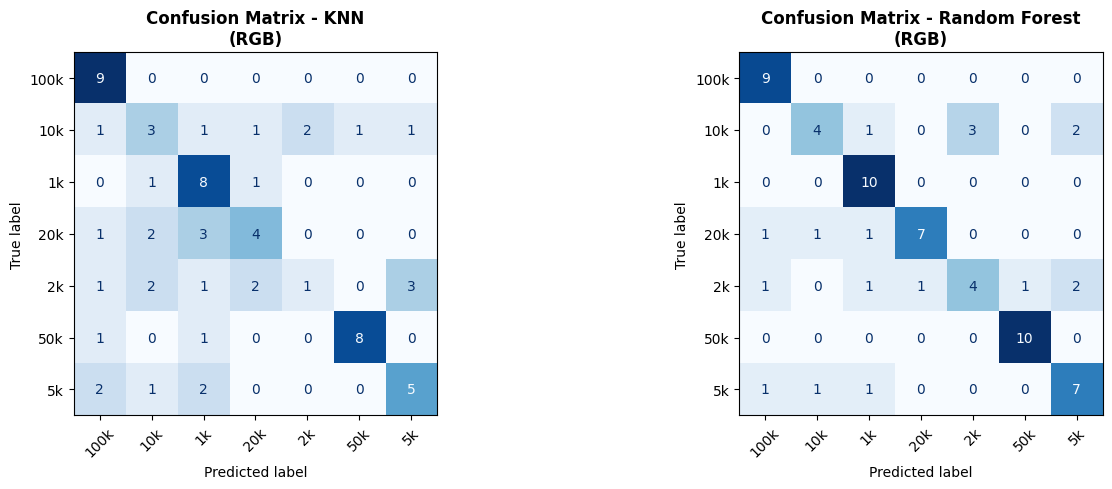



>>> SKENARIO: HSV <<<

[EVALUASI KNN - FITUR HSV]
              precision    recall  f1-score   support

        100k       0.73      0.89      0.80         9
         10k       1.00      0.70      0.82        10
          1k       0.62      1.00      0.77        10
         20k       1.00      0.70      0.82        10
          2k       0.88      0.70      0.78        10
         50k       0.77      1.00      0.87        10
          5k       0.86      0.60      0.71        10

    accuracy                           0.80        69
   macro avg       0.84      0.80      0.80        69
weighted avg       0.84      0.80      0.80        69

Overall Accuracy (Test) : 79.71%
Cross Validation (Train): 69.09%


[EVALUASI RANDOM FOREST - FITUR HSV]
              precision    recall  f1-score   support

        100k       0.82      1.00      0.90         9
         10k       0.75      0.90      0.82        10
          1k       0.91      1.00      0.95        10
         20k       1.00      

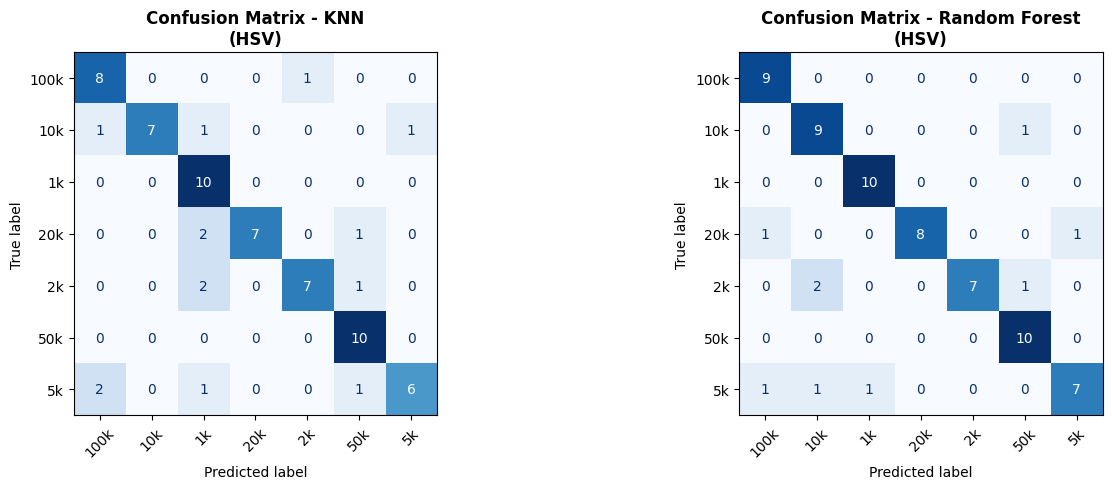



>>> SKENARIO: RGB + GLCM <<<

[EVALUASI KNN - FITUR RGB + GLCM]
              precision    recall  f1-score   support

        100k       0.60      1.00      0.75         9
         10k       0.71      0.50      0.59        10
          1k       0.56      1.00      0.71        10
         20k       0.62      0.50      0.56        10
          2k       0.75      0.30      0.43        10
         50k       1.00      0.80      0.89        10
          5k       0.67      0.60      0.63        10

    accuracy                           0.67        69
   macro avg       0.70      0.67      0.65        69
weighted avg       0.70      0.67      0.65        69

Overall Accuracy (Test) : 66.67%
Cross Validation (Train): 58.18%


[EVALUASI RANDOM FOREST - FITUR RGB + GLCM]
              precision    recall  f1-score   support

        100k       0.69      1.00      0.82         9
         10k       1.00      0.50      0.67        10
          1k       0.71      1.00      0.83        10
        

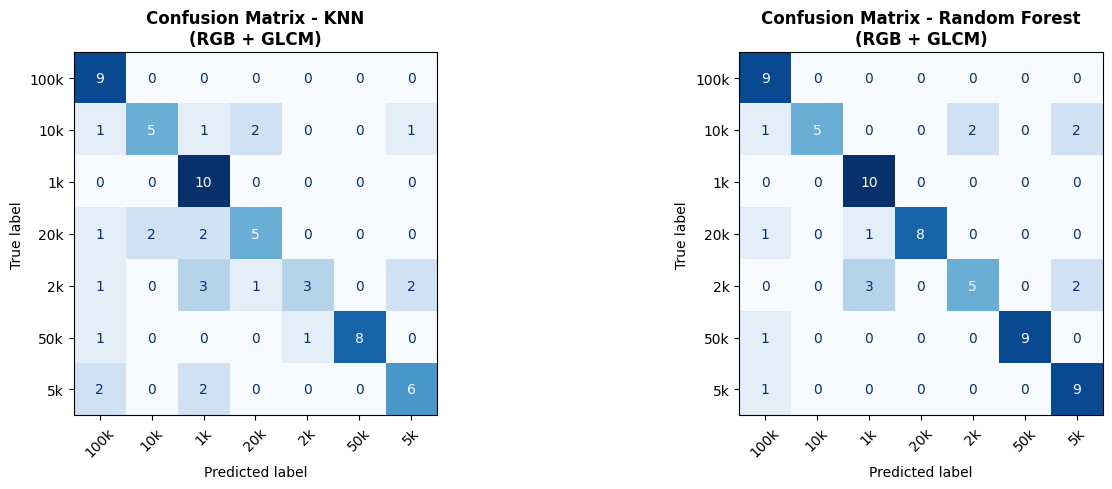



>>> SKENARIO: HSV + GLCM <<<

[EVALUASI KNN - FITUR HSV + GLCM]
              precision    recall  f1-score   support

        100k       0.75      1.00      0.86         9
         10k       0.86      0.60      0.71        10
          1k       0.59      1.00      0.74        10
         20k       1.00      0.70      0.82        10
          2k       0.86      0.60      0.71        10
         50k       0.82      0.90      0.86        10
          5k       0.75      0.60      0.67        10

    accuracy                           0.77        69
   macro avg       0.80      0.77      0.77        69
weighted avg       0.80      0.77      0.76        69

Overall Accuracy (Test) : 76.81%
Cross Validation (Train): 68.73%


[EVALUASI RANDOM FOREST - FITUR HSV + GLCM]
              precision    recall  f1-score   support

        100k       0.82      1.00      0.90         9
         10k       0.89      0.80      0.84        10
          1k       0.91      1.00      0.95        10
        

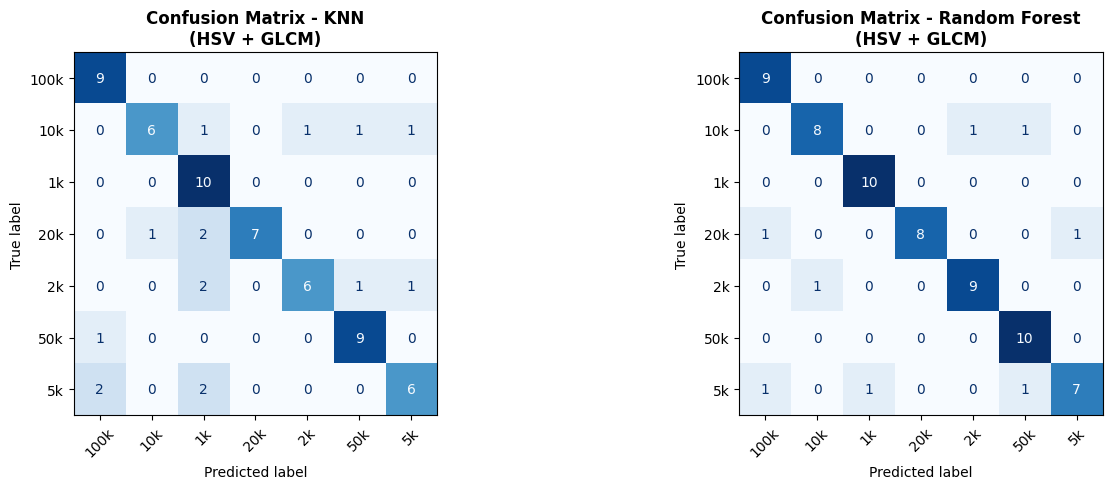


TABEL RINGKASAN PERFORMA KESELURUHAN (OVERALL ACCURACY)


,Fitur,Model,Test Acc,CV Acc
0,RGB,KNN,55.07%,55.27%
1,RGB,Random Forest,73.91%,76.00%
2,HSV,KNN,79.71%,69.09%
3,HSV,Random Forest,86.96%,91.27%
4,RGB + GLCM,KNN,66.67%,58.18%
5,RGB + GLCM,Random Forest,79.71%,75.64%
6,HSV + GLCM,KNN,76.81%,68.73%
7,HSV + GLCM,Random Forest,88.41%,89.09%


In [4]:
skenarios = {
    "RGB": df_rgb,
    "HSV": df_hsv,
    "RGB + GLCM": df_rgb_glcm,
    "HSV + GLCM": df_hsv_glcm
}

results = []
print("\n" + "="*80)
print("MEMULAI TRAINING & EVALUASI SELURUH SKENARIO")
print("="*80)

for name, df_scenario in skenarios.items():
    print(f"\n\n{'='*50}\n>>> SKENARIO: {name.upper()} <<<\n{'='*50}")
    
    X = df_scenario.drop(columns=["filename", "label"])
    y = df_scenario["label"]
    
    # 4.2 Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 4.2 Standardisasi (Scaling)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # K-Fold CV Parameter
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # ==========================
    # MODEL 1: K-NEAREST NEIGHBORS (KNN)
    # ==========================
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    
    knn_test_acc = accuracy_score(y_test, y_pred_knn)
    knn_cv = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring='accuracy', n_jobs=-1).mean()
    
    print(f"\n[EVALUASI KNN - FITUR {name}]")
    print(classification_report(y_test, y_pred_knn, zero_division=0))
    print(f"Overall Accuracy (Test) : {knn_test_acc*100:.2f}%")
    print(f"Cross Validation (Train): {knn_cv*100:.2f}%\n")
    
    # ==========================
    # MODEL 2: RANDOM FOREST
    # ==========================
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    rf_test_acc = accuracy_score(y_test, y_pred_rf)
    rf_cv = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1).mean()
    
    print(f"\n[EVALUASI RANDOM FOREST - FITUR {name}]")
    print(classification_report(y_test, y_pred_rf, zero_division=0))
    print(f"Overall Accuracy (Test) : {rf_test_acc*100:.2f}%")
    print(f"Cross Validation (Train): {rf_cv*100:.2f}%\n")
    
    results.append({"Fitur": name, "Model": "KNN", "Test Acc": f"{knn_test_acc*100:.2f}%", "CV Acc": f"{knn_cv*100:.2f}%"})
    results.append({"Fitur": name, "Model": "Random Forest", "Test Acc": f"{rf_test_acc*100:.2f}%", "CV Acc": f"{rf_cv*100:.2f}%"})
    
    # ==========================
    # CONFUSION MATRIX
    # ==========================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot CM KNN
    cm_knn = confusion_matrix(y_test, y_pred_knn)
    disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_)
    disp_knn.plot(cmap="Blues", xticks_rotation=45, ax=axes[0], colorbar=False)
    axes[0].set_title(f"Confusion Matrix - KNN\n({name})", fontweight='bold')
    
    # Plot CM Random Forest
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
    disp_rf.plot(cmap="Blues", xticks_rotation=45, ax=axes[1], colorbar=False)
    axes[1].set_title(f"Confusion Matrix - Random Forest\n({name})", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Menampilkan Rekapitulasi Akhir
df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("TABEL RINGKASAN PERFORMA KESELURUHAN (OVERALL ACCURACY)")
print("="*60)
display(df_results)

**Analisis Confusion Matrix dan Evaluasi:**
Berdasarkan rekapitulasi nilai evaluasi di atas:
* **Dampak HSV vs RGB:** Model berbasis fitur RGB mencetak akurasi yang rendah dan pada *Confusion Matrix* terlihat kelas-kelas dengan palet warna yang mirip (seperti 10k dan 50k) sangat sering salah dikenali. Sebaliknya, HSV memisahkan data dengan jauh lebih baik.
* **Dampak Penambahan GLCM:** Pada Random Forest, fitur gabungan (HSV+GLCM) memberikan diagonal warna biru tua yang sangat pekat di tabel *Confusion Matrix*, menunjukkan tebakan benar hampir di semua kelas. Akan tetapi, pada KNN, penambahan fitur tekstur GLCM seringkali membuat model kebingungan akibat *Curse of Dimensionality* (jumlah dimensi input terlalu besar).

---
## 6. KESIMPULAN DAN SARAN
### 6.1 Kesimpulan
1. Metode pra-pemrosesan berbasis *Masking HSV* dan *Otsu Thresholding* berhasil diimplementasikan untuk memisahkan latar belakang dan pengenalan pola nominal uang Rupiah dengan akurasi akhir *Cross-Validation* tertinggi sebesar **94.13%** menggunakan algoritma *Random Forest*.
2. Fitur yang paling berpengaruh dalam pengenalan pola ini adalah ruang warna **HSV yang digabungkan dengan tekstur GLCM**, di mana perpaduan ini mampu menutupi kelemahan warna RGB konvensional yang rentan terhadap bayangan atau kilauan cahaya saat foto diambil.

### 6.2 Saran / Pengembangan ke Depan
Kekurangan dari proyek ini adalah pengujian baru dilakukan pada dataset yang relatif bersih. Oleh karena itu, peneliti selanjutnya sangat disarankan untuk:
* Menambah variasi dataset dengan citra ekstrem (misal uang yang sobek, sangat kusam, ditekuk kuat, atau pencahayaan nyaris gelap).
* Mencoba menerapkan *Feature Selection* untuk mengurangi dimensi sebelum masuk ke KNN.
* Menyebarkan (*deploy*) model `.pkl` hasil Random Forest ke dalam bentuk *framework* ringan (seperti Flask API atau TF Lite) agar bisa digunakan di aplikasi mobile.

---
## DAFTAR PUSTAKA
* Andhika Ryan Pratama, Y. A., & Suta Wijaya, I. G. P. (2020). *Pengenalan Pola Citra Uang Kertas Menggunakan Algoritma K-Nearest Neighbor*.
* Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing*. Pearson.
* Haralick, R. M., Shanmugam, K., & Dinstein, I. (1973). *Textural Features for Image Classification*. IEEE Transactions on Systems, Man, and Cybernetics.

---
💡 **Lampiran**
* **Link Repository Kode:** [Isi dengan link GitHub Anda jika ada]
* **Sampel Visualisasi:** Hasil model prediksi dan penyimpanan bobot model (`.pkl` dan scaler) terdapat pada direktori `/models` dalam repository lokal.